In [2]:
import os
import math as m
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import linregress
import sys

In [3]:
print(1+1)

2


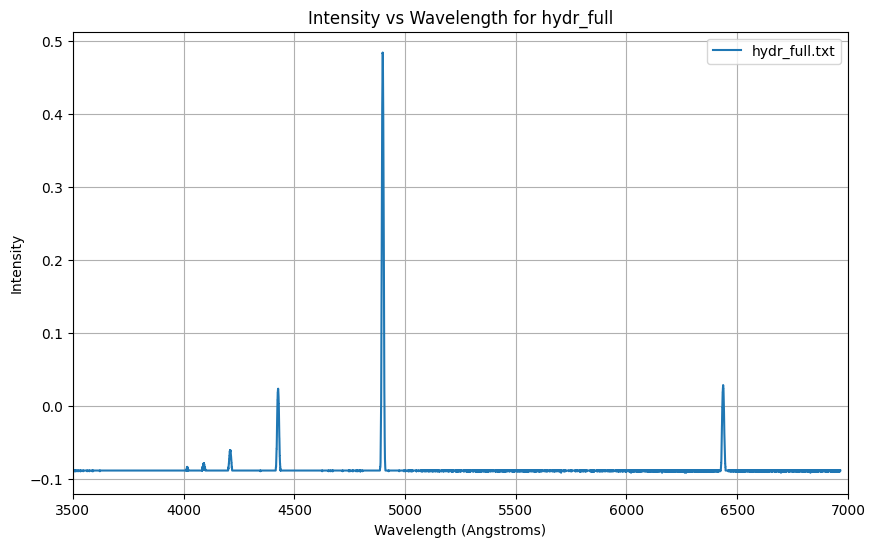

In [5]:
import importlib
import calib
importlib.reload(calib)
import spectrum
importlib.reload(spectrum)

sys.path.append('/workspaces/CP1-24-final/zbpetersbuf/advlab3data/')
file_contents = spectrum.read_files('hydr_full.txt')
plt.figure(figsize=(10, 6))

for file_path, data in file_contents.items():
    time = [0.99*point[0] + 35.5 for point in data]
    value = [point[1] for point in data]
    plt.plot(time, value, label=file_path.split('/')[-1])



plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Intensity')
plt.title(f'Intensity vs Wavelength for {'hydr_full'}')
plt.xlim(3500, 7000)
plt.legend()
plt.grid(True)
plt.show()

In [6]:
import importlib
import calib
importlib.reload(calib)
sys.path.append('/workspaces/CP1-24-final/zbpetersbuf/advlab3data/')
print(calib.fit_gaussian(data, 4000, 4050))
print(calib.fit_gaussian(data, 4050, 4100))
print(calib.fit_gaussian(data, 4190, 4250))
print(calib.fit_gaussian(data, 4400, 4480))
print(calib.fit_gaussian(data, 4850, 4950))
print(calib.fit_gaussian(data, 6410, 6460))

4021.6703101038697
4067.0364614340865
4216.946515091573
4435.548816515589
4912.946615128194
6429.172658618675


Linear Fit Equation: y = 1.10608x + -556.13681


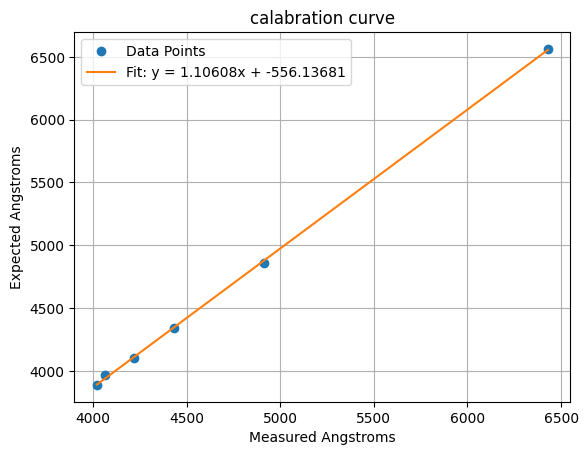

In [7]:
call_data = [(4021.67, 3889.056), (4067.036, 3970.1), (4216.9465, 4101.7), (4435.5488, 4340.49), (4912.9466,4861.33),(6429.172658,6562.79)]

x_vals, y_vals = zip(*call_data)
slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals)

print(f"Linear Fit Equation: y = {slope:.5f}x + {intercept:.5f}")

plt.plot(x_vals, y_vals, 'o', label='Data Points')
plt.plot(x_vals, [slope * x + intercept for x in x_vals], label=f'Fit: y = {slope:.5f}x + {intercept:.5f}')

plt.xlabel('Measured Angstroms')
plt.ylabel('Expected Angstroms')
plt.title('calabration curve')
plt.legend()
plt.grid(True)
plt.show()